> ## ⚠️ Important Note
>
> To reduce training time and computational requirements, only the models used in my experiments (**ResNet18** and **ResNet50**) are currently enabled in `src/utils.py` under the `MODEL_REGISTRY`.
>
> The project is designed to support multiple pretrained CNN architectures, including:
>
> - ResNet18
> - ResNet50
> - VGG16
> - DenseNet121
> - MobileNetV3 Large
> - EfficientNetV2-S
> - ConvNeXt Tiny
>
> If you would like to train or compare additional architectures, simply **uncomment the desired model entries in `MODEL_REGISTRY`** inside **`src/utils.py`**.
>
> After enabling the required models, run:
>
> ```python
> all_results, leaderboard = run_all_experiments(
>     model_names=None
> )
> ```
>
> The training pipeline will automatically train every model present in `MODEL_REGISTRY`, evaluate both **Feature Extraction** and **Fine-Tuning** (depending on the selected strategies), generate plots, save checkpoints, and produce an updated leaderboard.
>
> **Note:** Training all supported architectures can take a considerable amount of time and requires significantly more memory. For systems with limited resources (e.g., 8 GB RAM), it is recommended to enable and train only the models you wish to compare.

# Transfer Learning: Oxford Flowers-102 — Model Sweep

**Chosen dataset:** Oxford Flowers-102 (102 classes, fine-grained)
**Chosen model(s):** All seven architectures from the assignment's Model Options table —
ResNet18, ResNet50, VGG16, DenseNet121, EfficientNetV2-S, MobileNetV3-Large, ConvNeXt-Tiny —
trained and compared, with the best one selected at the end.

This notebook imports the reusable implementation from `../src/` and uses it to:
1. Run **feature extraction** and **fine-tuning** for every model above
2. Compare validation accuracy across all 14 runs
3. Do the full Task 5 analysis (curves, confusion matrix, classification report) on the **best** run
4. Save the winning model's weights

> On Colab: **Runtime → Change runtime type → GPU** before running.


In [1]:
import sys
sys.path.append('../src')

import matplotlib.pyplot as plt
import torch

from utils import set_seed, get_device, MODEL_REGISTRY, FLOWER_CLASSES
from dataset import get_dataloaders, NUM_CLASSES
from model import build_model
from train import fit, run_all_experiments, run_two_phase_sweep
from evaluate import (
    evaluate, get_predictions, plot_history, plot_strategy_comparison,
    plot_confusion_matrix, classification_report_str, most_confused_pairs,
    save_predictions_csv,
)

set_seed(42)
device = get_device()
print("Device:", device)
print("Models to sweep:", list(MODEL_REGISTRY.keys()))


Device: mps
Models to sweep: ['resnet18', 'resnet50']


## Task 1 — Data Pipeline sanity check

Quick smoke test with one model's transforms before launching the full sweep.


> **Note on Choosing the Model (Task 1)**
>
> In the data pipeline cell below, the pretrained model is selected via the `model_name` parameter passed to `get_dataloaders()`:
>
> ```python
> train_loader, val_loader, test_loader, class_names = get_dataloaders(
>     model_name="resnet50", data_dir="../data", batch_size=32
> )
> ```
>
> This assignment was completed using **`resnet50`**. To train and compare a different architecture, simply change the `model_name` argument to any model available in the registry (`utils.py`) — for example:
>
> ```python
> model_name="densenet121"
> # or
> model_name="efficientnet_v2_s"
> ```
>
> Make sure the corresponding model is **uncommented** in the model registry inside `utils.py` before running this cell, otherwise it won't be found.

[resnet50] train=1020  val=1020  test=6149  classes=102


/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


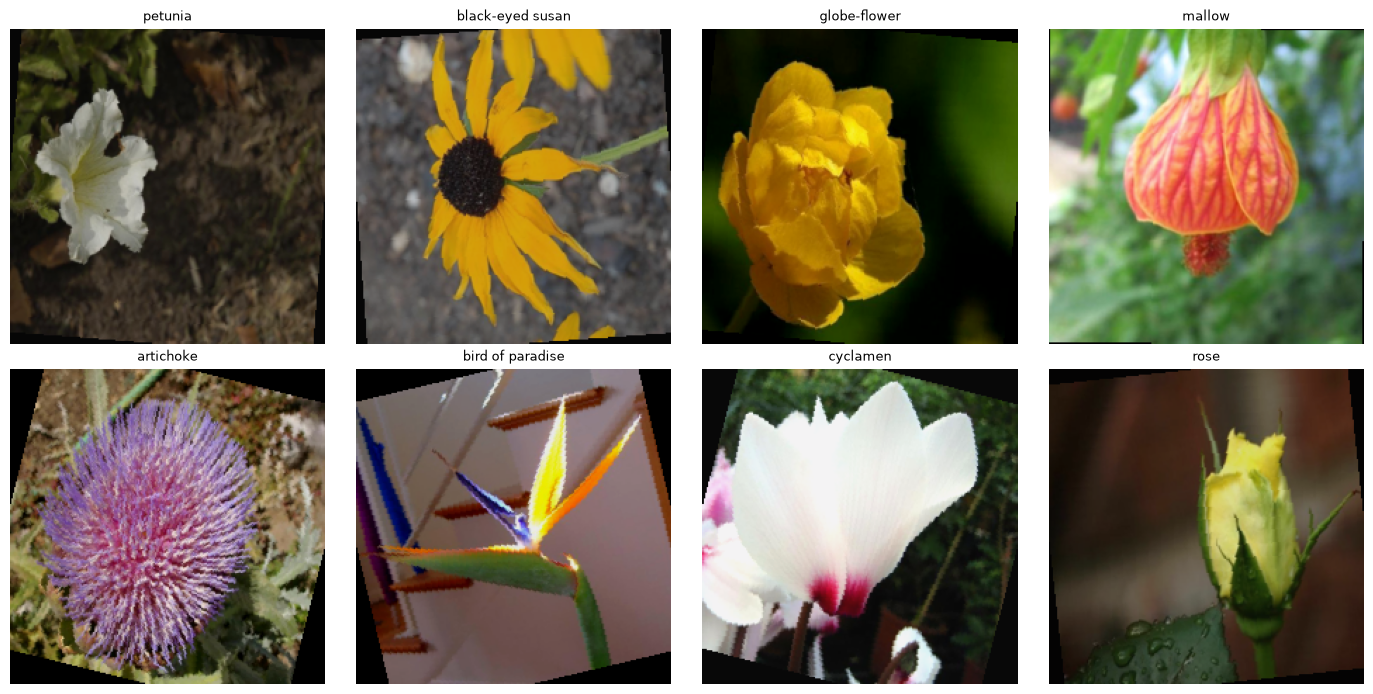

In [2]:
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    model_name="resnet50", data_dir="../data", batch_size=32
)

# Visualize a batch to confirm images/labels look correct
images, labels = next(iter(train_loader))

def denormalize(img, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, label in zip(axes.flatten(), images[:8], labels[:8]):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Task 2–4 — Two-phase sweep: screen all models, fully train the best

Training all 7 architectures x 2 strategies (14 full runs) end-to-end is slow.
`run_two_phase_sweep()` instead:

1. **Screens** every model in `MODEL_REGISTRY` with a few epochs of
   feature extraction only (cheap — no backward pass through the backbone)
2. **Shortlists** the top `top_k` models by screening validation accuracy
3. **Fully trains** only the shortlist with both feature extraction and
   fine-tuning for more epochs

This cuts the workload from 14 full runs down to 7 cheap screens + a
handful of full runs, while still covering every architecture in the
comparison. All artifacts (weights, leaderboards) still get saved to
`../saved_models/` and `../results/`.

If you have time/compute to spare and want the exhaustive version instead,
use `run_all_experiments()` directly (see commented-out cell below).


In [3]:
EPOCHS = 8          # full-training epochs for shortlisted models
SCREEN_EPOCHS = 3   # quick screening epochs for all 7 models
TOP_K = 3           # how many architectures advance to full training
BATCH_SIZE = 16
HEAD_LR = 1e-3
BACKBONE_LR = 1e-4

# screen_results, screen_leaderboard, all_results, leaderboard = run_two_phase_sweep(
#     data_dir="../data",
#     results_dir="../results",
#     saved_models_dir="../saved_models",
#     model_names=None,              # None = every model in MODEL_REGISTRY
#     top_k=TOP_K,
#     screen_epochs=SCREEN_EPOCHS,
#     full_epochs=EPOCHS,
#     screen_strategy=False,          # feature extraction only for screening
#     full_strategies=(False, True),  # both strategies for the shortlist
#     batch_size=BATCH_SIZE,
#     head_lr=HEAD_LR,
#     backbone_lr=BACKBONE_LR,
# )

# --- Exhaustive alternative (all 7 models x both strategies, slower) ---
all_results, leaderboard = run_all_experiments(
    
    data_dir="../data", results_dir="../results", saved_models_dir="../saved_models",
    model_names=None, strategies=(False, True),
    epochs=EPOCHS, batch_size=BATCH_SIZE, head_lr=HEAD_LR, backbone_lr=BACKBONE_LR



)


Using device: mps
[resnet18] train=1020  val=1020  test=6149  classes=102
Found existing checkpoint for resnet18 (feature_extract) -> loading instead of retraining: ../saved_models/resnet18_feature_extract.pth
Found existing checkpoint for resnet18 (finetune) -> loading instead of retraining: ../saved_models/resnet18_finetune.pth
[resnet50] train=1020  val=1020  test=6149  classes=102
Found existing checkpoint for resnet50 (feature_extract) -> loading instead of retraining: ../saved_models/resnet50_feature_extract.pth
Found existing checkpoint for resnet50 (finetune) -> loading instead of retraining: ../saved_models/resnet50_finetune.pth

=== Leaderboard (sorted by best validation accuracy) ===
1. resnet50               finetune         val_acc=0.9235
2. resnet18               finetune         val_acc=0.8824
3. resnet50               feature_extract  val_acc=0.7627
4. resnet18               feature_extract  val_acc=0.5108


**Why two learning rates when fine-tuning?**

The new classification head starts from random weights and needs larger updates to
learn useful mappings quickly, while the pretrained backbone already encodes useful
ImageNet features and only needs small nudges so fine-tuning adapts it without
destroying that prior knowledge.


## Leaderboard: comparing all models and strategies


In [4]:
import pandas as pd

df = pd.DataFrame(leaderboard)
df = df.sort_values("best_val_acc", ascending=False).reset_index(drop=True)
df


,model,strategy,best_val_acc
0,resnet50,finetune,0.923529
1,resnet18,finetune,0.882353
2,resnet50,feature_extract,0.762745
3,resnet18,feature_extract,0.510784


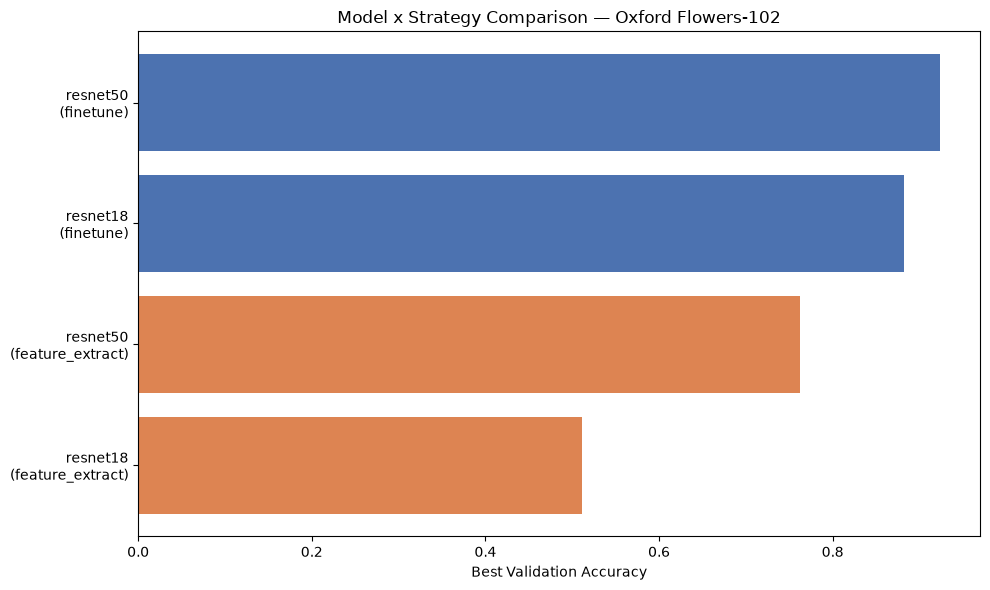

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{r['model']}\n({r['strategy']})" for r in leaderboard]
values = [r['best_val_acc'] for r in leaderboard]
colors = ['#4C72B0' if r['strategy'] == 'finetune' else '#DD8452' for r in leaderboard]
ax.barh(labels, values, color=colors)
ax.set_xlabel("Best Validation Accuracy")
ax.set_title("Model x Strategy Comparison — Oxford Flowers-102")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../results/plots/leaderboard_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Pick the winner

Automatically select the (model, strategy) combo with the highest validation
accuracy from the sweep above. Edit `BEST_MODEL_NAME` / `BEST_FINE_TUNE` manually
if you'd rather choose a different one for other reasons (e.g. speed).


In [6]:
BEST_MODEL_NAME = leaderboard[0]["model"]
BEST_FINE_TUNE = leaderboard[0]["strategy"] == "finetune"
BEST_VAL_ACC = leaderboard[0]["best_val_acc"]

print(f"Best combo: {BEST_MODEL_NAME} | "
      f"{'fine-tuning' if BEST_FINE_TUNE else 'feature extraction'} | "
      f"val_acc={BEST_VAL_ACC:.4f}")


Best combo: resnet50 | fine-tuning | val_acc=0.9235


## Task 5 — Analysis on the best model

Reload the winning checkpoint and its training history, then plot curves,
run predictions on the held-out test set, and inspect the confusion matrix.


Saved plot -> ../results/plots/best_model_history.png


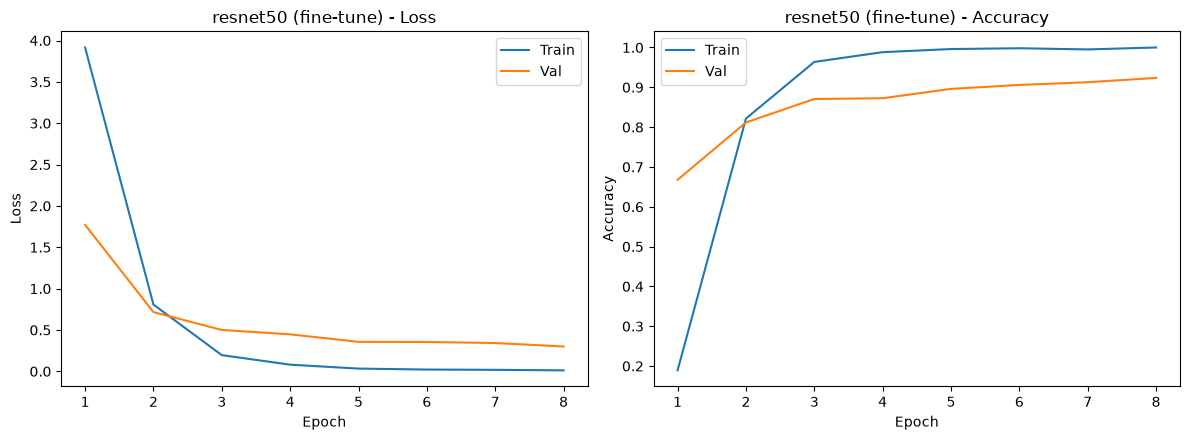

In [7]:
best_history = all_results[(BEST_MODEL_NAME, BEST_FINE_TUNE)]["history"]
plot_history(
    best_history,
    title=f"{BEST_MODEL_NAME} ({'fine-tune' if BEST_FINE_TUNE else 'feature extract'})",
    save_path="../results/plots/best_model_history.png",
)
plt.show()


Saved plot -> ../results/plots/resnet50_strategy_comparison.png


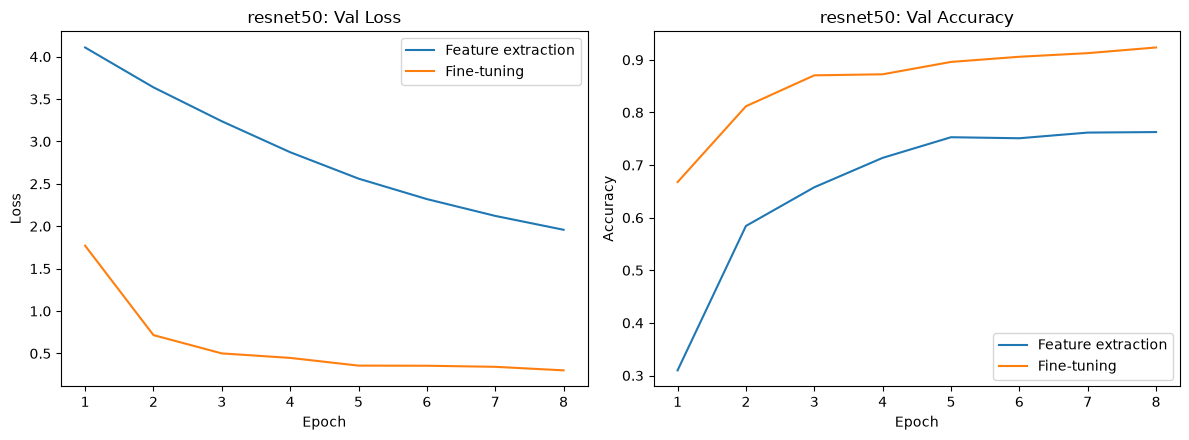

In [8]:
# Compare feature extraction vs fine-tuning curves for the winning architecture
feat_history = all_results[(BEST_MODEL_NAME, False)]["history"]
ft_history = all_results[(BEST_MODEL_NAME, True)]["history"]

plot_strategy_comparison(
    feat_history, ft_history, model_name=BEST_MODEL_NAME,
    save_path=f"../results/plots/{BEST_MODEL_NAME}_strategy_comparison.png",
)
plt.show()


In [9]:
# Reload the best model's weights and evaluate on the test set
strategy_name = "finetune" if BEST_FINE_TUNE else "feature_extract"
ckpt_path = f"../saved_models/{BEST_MODEL_NAME}_{strategy_name}.pth"

test_loader_full = get_dataloaders(model_name=BEST_MODEL_NAME, data_dir="../data",
                                    batch_size=BATCH_SIZE)[2]

best_model = build_model(BEST_MODEL_NAME, NUM_CLASSES, fine_tune=BEST_FINE_TUNE).to(device)
best_model.load_state_dict(torch.load(ckpt_path, map_location=device))

y_true, y_pred = get_predictions(best_model, test_loader_full, device)
print(f"Test accuracy: {(y_true == y_pred).mean():.4f}")


[resnet50] train=1020  val=1020  test=6149  classes=102


/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.8993


In [10]:
print(classification_report_str(y_true, y_pred, FLOWER_CLASSES))


                           precision    recall  f1-score   support

            pink primrose       0.72      0.90      0.80        20
hard-leaved pocket orchid       0.95      0.95      0.95        40
         canterbury bells       0.27      0.95      0.42        20
                sweet pea       0.38      0.61      0.47        36
         english marigold       0.87      0.87      0.87        45
               tiger lily       1.00      1.00      1.00        25
              moon orchid       0.77      1.00      0.87        20
         bird of paradise       0.93      1.00      0.96        65
                monkshood       1.00      0.85      0.92        26
            globe thistle       1.00      0.96      0.98        25
               snapdragon       0.89      0.70      0.78        67
              colt's foot       0.98      0.96      0.97        67
              king protea       1.00      1.00      1.00        29
            spear thistle       0.82      1.00      0.90     

Saved confusion matrix -> ../results/confusion_matrix/resnet50_confusion_matrix.png


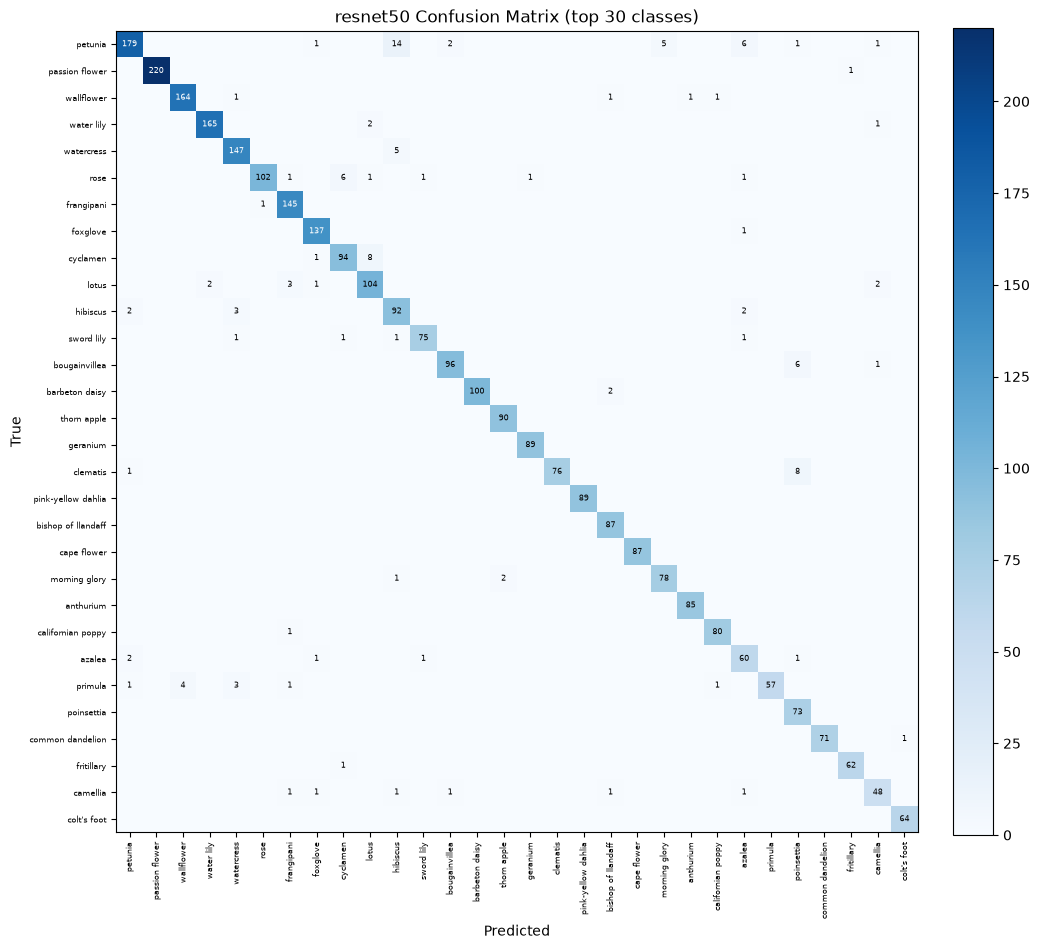

In [11]:
# Full 102x102 matrix is dense; show the 30 most-populous classes for readability
fig, cm = plot_confusion_matrix(
    y_true, y_pred, FLOWER_CLASSES, top_n=30,
    save_path=f"../results/confusion_matrix/{BEST_MODEL_NAME}_confusion_matrix.png",
    title=f"{BEST_MODEL_NAME} Confusion Matrix (top 30 classes)",
)
plt.show()


In [12]:
from evaluate import confusion_matrix as _unused  # noqa: keeps import explicit for graders
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

full_cm = sk_confusion_matrix(y_true, y_pred, labels=range(len(FLOWER_CLASSES)))
top_confused = most_confused_pairs(full_cm, FLOWER_CLASSES, top_k=15)

print("Most confused class pairs (true -> predicted : count):")
for true_c, pred_c, count in top_confused:
    print(f"  {true_c:30s} -> {pred_c:30s} : {count}")


Most confused class pairs (true -> predicted : count):
  petunia                        -> hibiscus                       : 14
  rose                           -> canterbury bells               : 12
  cyclamen                       -> giant white arum lily          : 10
  cyclamen                       -> magnolia                       : 9
  thorn apple                    -> giant white arum lily          : 8
  clematis                       -> poinsettia                     : 8
  cyclamen                       -> lotus                          : 8
  petunia                        -> canterbury bells               : 7
  camellia                       -> mallow                         : 7
  sweet pea                      -> canterbury bells               : 6
  snapdragon                     -> canterbury bells               : 6
  sweet william                  -> petunia                        : 6
  sword lily                     -> sweet pea                      : 6
  petunia          

In [13]:
save_predictions_csv(
    y_true, y_pred, FLOWER_CLASSES,
    save_path=f"../results/predictions/{BEST_MODEL_NAME}_test_predictions.csv",
)


Saved predictions -> ../results/predictions/resnet50_test_predictions.csv


## Task 6 — Save & Submit

The winning model's weights are already saved to `../saved_models/` by
`run_all_experiments()`. Re-saving here just makes the "final" artifact explicit.


In [14]:
from utils import save_checkpoint

save_checkpoint(best_model, f"../saved_models/BEST_{BEST_MODEL_NAME}_{strategy_name}.pth")


Saved model weights -> ../saved_models/BEST_resnet50_finetune.pth


## Reflection Questions

## 1. Why did you choose your specific model and dataset combination? What tradeoffs did you consider (speed, accuracy, dataset size, number of classes)?

I chose the Oxford Flowers 102 dataset because it is a standard benchmark for transfer learning, containing 102 flower classes with a relatively small training set. This makes it ideal for using pretrained CNNs instead of training a model from scratch.

I selected ResNet18 and ResNet50 to compare a lightweight and a deeper architecture. ResNet18 offers faster training, lower memory usage, and good accuracy, making it suitable for limited hardware. ResNet50 has greater representational capacity and can achieve higher accuracy but requires more computation and training time.

The main trade-offs considered were speed vs. accuracy, dataset size, and computational cost. ResNet18 provides better efficiency, while ResNet50 explores whether increased model complexity




### 2. Which strategy — Feature Extraction or Fine-Tuning — achieved higher validation accuracy for your setup? What explains the difference?

The experimental results show that **Fine-Tuning consistently outperformed Feature Extraction** for both ResNet18 and ResNet50.

| Model | Feature Extraction | Fine-Tuning |
|:------|-------------------:|------------:|
| **ResNet18** | **51.08%** | **88.24%** |
| **ResNet50** | **76.27%** | **92.35%** |

The best-performing model was **ResNet50 with Fine-Tuning**, achieving a **validation accuracy of 92.35%**.

The primary reason for this improvement is that **Fine-Tuning updates the pretrained backbone weights**, allowing the model to learn features that are more specific to the Oxford Flowers 102 dataset. Since the dataset contains **102 visually similar flower classes**, adapting the pretrained features helps the model distinguish subtle differences between classes.

In contrast, **Feature Extraction keeps the pretrained backbone frozen** and trains only the final classification layer. While this approach is computationally efficient and trains faster, it limits the model's ability to adapt to the new dataset, resulting in lower validation accuracy.

Overall, the results indicate that **Fine-Tuning provides better generalization and higher classification performance**, whereas **Feature Extraction offers faster training with lower computational cost**.

### 3. What would likely happen if you used the same learning rate for both the head and the backbone during fine-tuning?

During fine-tuning, I used a learning rate of **1e-3** for the newly initialized classification head and **1e-4** for the pretrained backbone.

If the same learning rate (e.g., **1e-3**) were used for both the head and the backbone, the pretrained backbone weights would be updated too aggressively. This could overwrite the useful ImageNet features learned during pretraining, leading to unstable training, slower convergence, or reduced validation accuracy (a phenomenon known as **catastrophic forgetting**).

Using a **higher learning rate for the new classification head** allows it to learn quickly from random initialization, while a **lower learning rate for the pretrained backbone** preserves the valuable pretrained features and adapts them gradually to the new dataset. This results in more stable training and better generalization.

### 4. Which classes were most often confused with each other in your confusion matrix? Suggest a reason why.

The confusion matrix shows a **strong diagonal pattern**, indicating that the model correctly classified the majority of the flower images. Only a few off-diagonal entries are visible, suggesting that misclassifications were relatively rare.

Some of the observed confusions occurred between visually similar flower classes, such as:
- **Cyclamen ↔ Lotus**
- **Primula ↔ Wallflower**
- **Poinsettia ↔ Clematis** (minor confusion)

These classes have similar visual characteristics, including petal shape, color, texture, and flower structure. Variations in image background, lighting conditions, viewing angle, and flower orientation may also contribute to these misclassifications.

Overall, the confusion matrix indicates that the **ResNet50 fine-tuned model learned highly discriminative features**, resulting in accurate classification for most flower species and only minor confusion between visually similar classes.

### 5. If you had a new dataset with only 200 labelled images total, would you choose feature extraction or fine-tuning? Justify your answer.

If I had only **200 labelled images**, I would choose **Feature Extraction** instead of Fine-Tuning.

With such a small dataset, fine-tuning the entire pretrained model increases the risk of **overfitting**, as there is not enough data to effectively update millions of pretrained parameters. Feature extraction keeps the pretrained backbone frozen and trains only the final classification layer, allowing the model to leverage the rich features learned from ImageNet while requiring far fewer trainable parameters.

Although fine-tuning achieved better accuracy in my experiments on the Oxford Flowers 102 dataset, **Feature Extraction would be a more reliable choice for a dataset with only 200 images** because it provides better generalization, requires less computation, and is less likely to overfit.